In [3]:
# ============================================================
# Project 2: Data Classification Using AI
# Algorithm : K-Nearest Neighbors (KNN)
# Dataset   : Iris Benchmark
# ============================================================


# ── STEP 0: Install / import all required libraries ──────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score,
)

In [4]:
# ── STEP 1: Load & explore the Iris dataset ──────────────────
iris = load_iris()

# Convert to a DataFrame for easier exploration
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df["target"] = iris.target
df["species"] = df["target"].map(
    {0: "Setosa", 1: "Versicolor", 2: "Virginica"}
)

print("=" * 50)
print("Dataset Overview")
print("=" * 50)
print(f"Total Samples  : {len(df)}")
print(f"Total Features : {len(iris.feature_names)}")
print(f"Classes        : {list(iris.target_names)}")
print()
print(df.head(10))
print()
print("Class distribution:")
print(df["species"].value_counts())


Dataset Overview
Total Samples  : 150
Total Features : 4
Classes        : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5             

In [5]:
# ── STEP 2: Prepare features (X) and labels (y) ──────────────
X = iris.data   # shape (150, 4)  →  4 features per sample
y = iris.target # shape (150,)    →  0 / 1 / 2

In [6]:
# ── STEP 3: Feature Scaling with StandardScaler ──────────────
# KNN is distance-based, so unscaled features bias the model.
# StandardScaler transforms each feature to mean=0, variance=1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nRaw feature sample      :", X[0])
print("Scaled feature sample   :", X_scaled[0].round(3))


Raw feature sample      : [5.1 3.5 1.4 0.2]
Scaled feature sample   : [-0.901  1.019 -1.34  -1.315]


In [7]:
# ── STEP 4: Train / Test Split (80 % train – 20 % test) ──────
# shuffle=True removes any ordering bias in the original data.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")


Training samples : 120
Testing  samples : 30


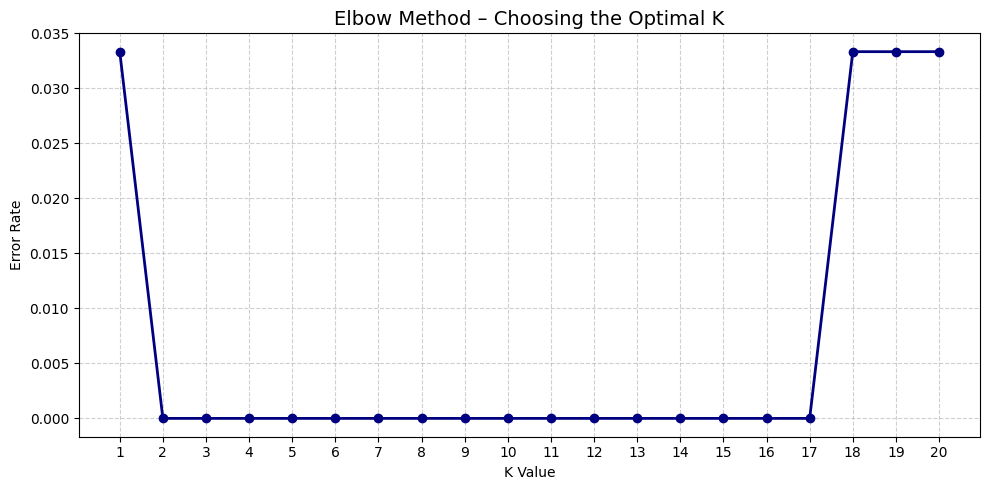


Elbow curve saved as 'elbow_curve.png'


In [8]:
# ── STEP 5: Find the Optimal K (Elbow Method) ────────────────
# Try K values from 1 to 20 and record the error rate each time.
error_rates = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, preds))

# Plot the elbow curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, error_rates, marker="o", color="navy", linewidth=2)
plt.title("Elbow Method – Choosing the Optimal K", fontsize=14)
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.xticks(k_range)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("elbow_curve.png", dpi=150)
plt.show()
print("\nElbow curve saved as 'elbow_curve.png'")

In [9]:
# ── STEP 6: Train the Final KNN Model (K = 5) ────────────────
BEST_K = 5  # change this value after inspecting the elbow curve

model = KNeighborsClassifier(n_neighbors=BEST_K)
model.fit(X_train, y_train)          # FIT  – memorise the training map
predictions = model.predict(X_test)  # PREDICT – apply learned logic

In [10]:
# ── STEP 7: Evaluate the Model ───────────────────────────────
accuracy = accuracy_score(y_test, predictions)
f1       = f1_score(y_test, predictions, average="weighted")

print("\n" + "=" * 50)
print(f"Model Results  (K = {BEST_K})")
print("=" * 50)
print(f"Accuracy  : {accuracy * 100:.2f} %")
print(f"F1 Score  : {f1:.4f}")
print()
print("Classification Report:")
print(
    classification_report(
        y_test, predictions, target_names=iris.target_names
    )
)


Model Results  (K = 5)
Accuracy  : 100.00 %
F1 Score  : 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



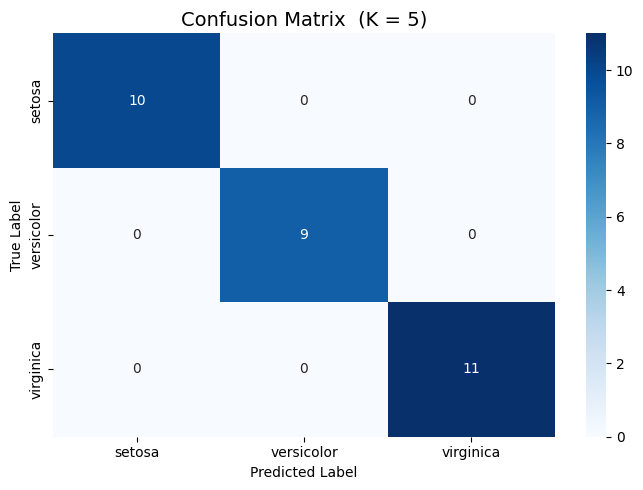

Confusion matrix saved as 'confusion_matrix.png'


In [11]:
# ── STEP 8: Confusion Matrix Heatmap ─────────────────────────
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
)
plt.title(f"Confusion Matrix  (K = {BEST_K})", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved as 'confusion_matrix.png'")

In [12]:
# ── STEP 9: Predict a Brand-New Sample ───────────────────────
# Provide raw measurements in cm: [sepal_len, sepal_wid, petal_len, petal_wid]
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

# Scale the new sample using the SAME scaler fitted on training data
new_sample_scaled = scaler.transform(new_sample)

prediction_index = model.predict(new_sample_scaled)[0]
predicted_class  = iris.target_names[prediction_index]

print(f"\nNew sample measurements : {new_sample[0]}")
print(f"Predicted species       : {predicted_class.upper()}")


New sample measurements : [5.1 3.5 1.4 0.2]
Predicted species       : SETOSA


In [13]:
# ── BONUS: Compare Multiple K Values ─────────────────────────
print("\n" + "=" * 50)
print("K Comparison Table")
print("=" * 50)
print(f"{'K':>4}  {'Accuracy':>10}  {'F1 Score':>10}")
print("-" * 30)
for k in [1, 3, 5, 7, 9, 11]:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    preds_temp = knn_temp.predict(X_test)
    acc_temp = accuracy_score(y_test, preds_temp)
    f1_temp  = f1_score(y_test, preds_temp, average="weighted")
    print(f"{k:>4}  {acc_temp*100:>9.2f}%  {f1_temp:>10.4f}")


K Comparison Table
   K    Accuracy    F1 Score
------------------------------
   1      96.67%      0.9664
   3     100.00%      1.0000
   5     100.00%      1.0000
   7     100.00%      1.0000
   9     100.00%      1.0000
  11     100.00%      1.0000
